In [501]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import seaborn as sns

from sklearn import preprocessing
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV, Ridge
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score

from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

## 1. Датасет

https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

Price of Used Toyota Corolla Cars

In [502]:
df = pd.read_csv("ToyotaCorolla.csv", index_col=0)

## 2. EDA

In [503]:
df.info()

<class 'pandas.DataFrame'>
Index: 1436 entries, 1 to 1442
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Model              1436 non-null   str  
 1   Price              1436 non-null   int64
 2   Age_08_04          1436 non-null   int64
 3   Mfg_Month          1436 non-null   int64
 4   Mfg_Year           1436 non-null   int64
 5   KM                 1436 non-null   int64
 6   Fuel_Type          1436 non-null   str  
 7   HP                 1436 non-null   int64
 8   Met_Color          1436 non-null   int64
 9   Color              1436 non-null   str  
 10  Automatic          1436 non-null   int64
 11  CC                 1436 non-null   int64
 12  Doors              1436 non-null   int64
 13  Cylinders          1436 non-null   int64
 14  Gears              1436 non-null   int64
 15  Quarterly_Tax      1436 non-null   int64
 16  Weight             1436 non-null   int64
 17  Mfr_Guarantee      1436 non-nu

In [504]:
df.head()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,...,0,1,0,0,0,1,0,0,0,0
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,...,1,1,0,1,0,1,0,0,0,0


In [505]:
df.shape

(1436, 38)

In [506]:
df.isna().sum()

Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [507]:
df = df.drop_duplicates()
df.shape

(1435, 38)

Таблица ниже потребуется для работы с признакми и их изменения

In [508]:
df1 = pd.DataFrame([
    [col, df[col].dtype, df[col].nunique()] 
    for col in df.columns
], columns=['Column', 'Dtype', 'Unique_Count'])
df1

,Column,Dtype,Unique_Count
0,Model,str,319
1,Price,int64,236
2,Age_08_04,int64,77
3,Mfg_Month,int64,12
4,Mfg_Year,int64,7
5,KM,int64,1263
6,Fuel_Type,str,3
7,HP,int64,12
8,Met_Color,int64,2
9,Color,str,10


In [509]:
df1[df1['Unique_Count'] >2][df1['Dtype'] == 'int64']['Column'].to_numpy()

C:\Users\admin\AppData\Local\Temp\ipykernel_13128\2311946563.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1[df1['Unique_Count'] >2][df1['Dtype'] == 'int64']['Column'].to_numpy()


array(['Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'CC',
       'Doors', 'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period'],
      dtype=object)

Расширенная статистика по числовым колонкам с множественными значениями(отлично от 0 или 1)

In [510]:
numeric_columns = ['Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'CC',
       'Doors', 'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period']
result_numeric = df.loc[:, numeric_columns]

stats = result_numeric.agg(['min', 'max', 'mean', 'median'])
modes = result_numeric.mode().iloc[0]
stats.loc['mode'] = modes
stats

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,CC,Doors,Gears,Quarterly_Tax,Weight,Guarantee_Period
min,4350.000000,1.000000,1.000000,1998.0000,1.000000,69.000000,1300.000000,2.000000,3.000000,19.000000,1000.000000,3.000000
max,32500.000000,80.000000,12.000000,2004.0000,243000.000000,192.000000,16000.000000,5.000000,6.000000,283.000000,1615.000000,36.000000
mean,10720.915679,55.980488,5.551916,1999.6223,68571.782578,101.491986,1576.560976,4.032753,5.026481,87.020209,1072.287108,3.816028
median,9900.000000,61.000000,5.000000,1999.0000,63451.000000,110.000000,1600.000000,4.000000,5.000000,85.000000,1070.000000,3.000000
mode,8950.000000,68.000000,1.000000,1999.0000,36000.000000,110.000000,1600.000000,5.000000,5.000000,85.000000,1075.000000,3.000000


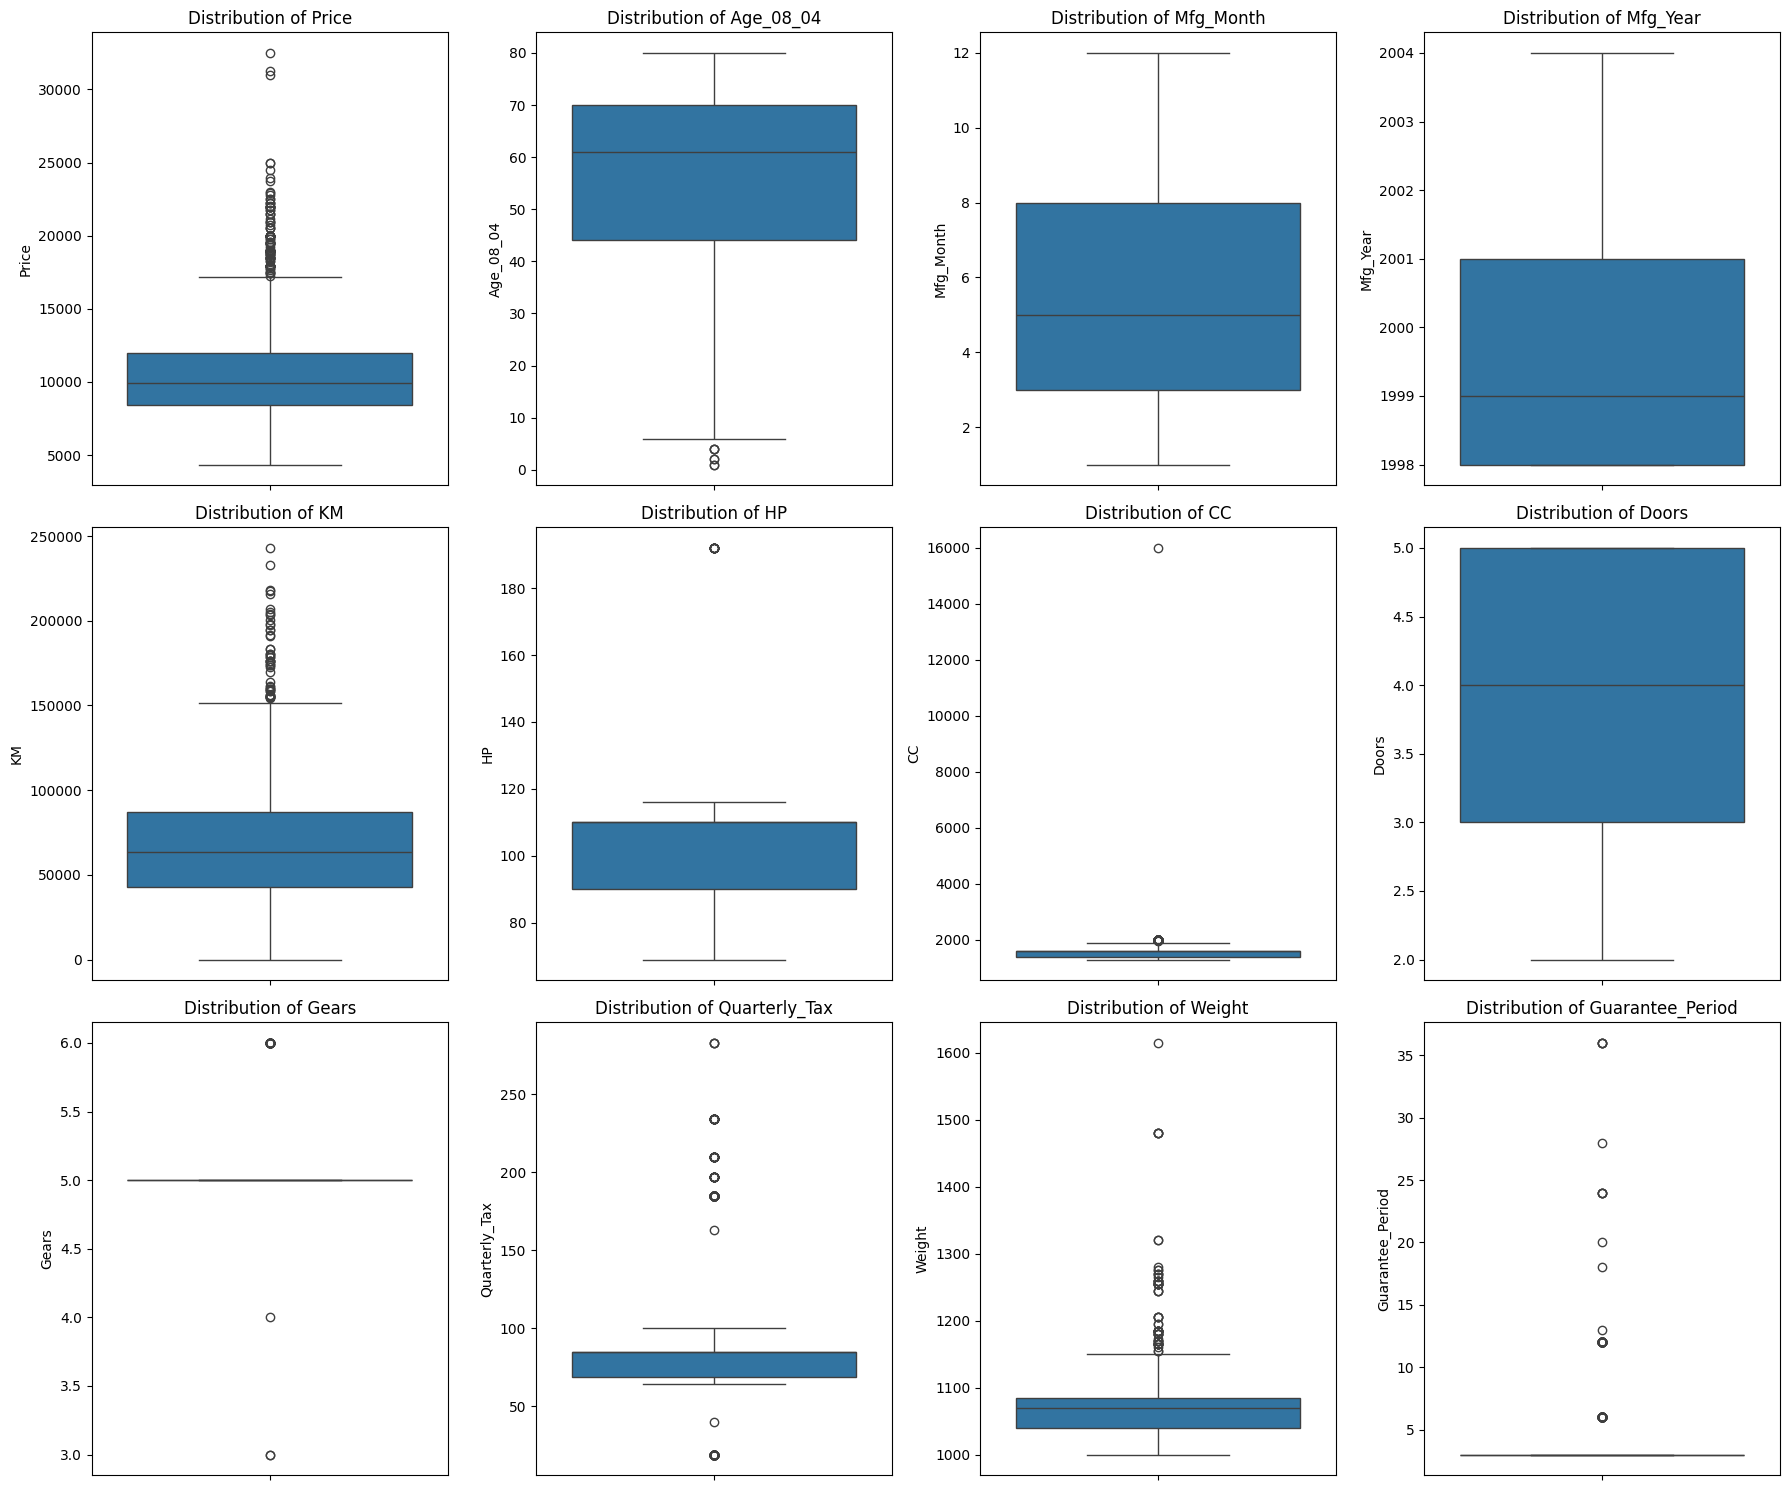

In [511]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(numeric_columns, 1): 
    plt.subplot(3, 4, i)
    sns.boxplot(data=df, y=column) 
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

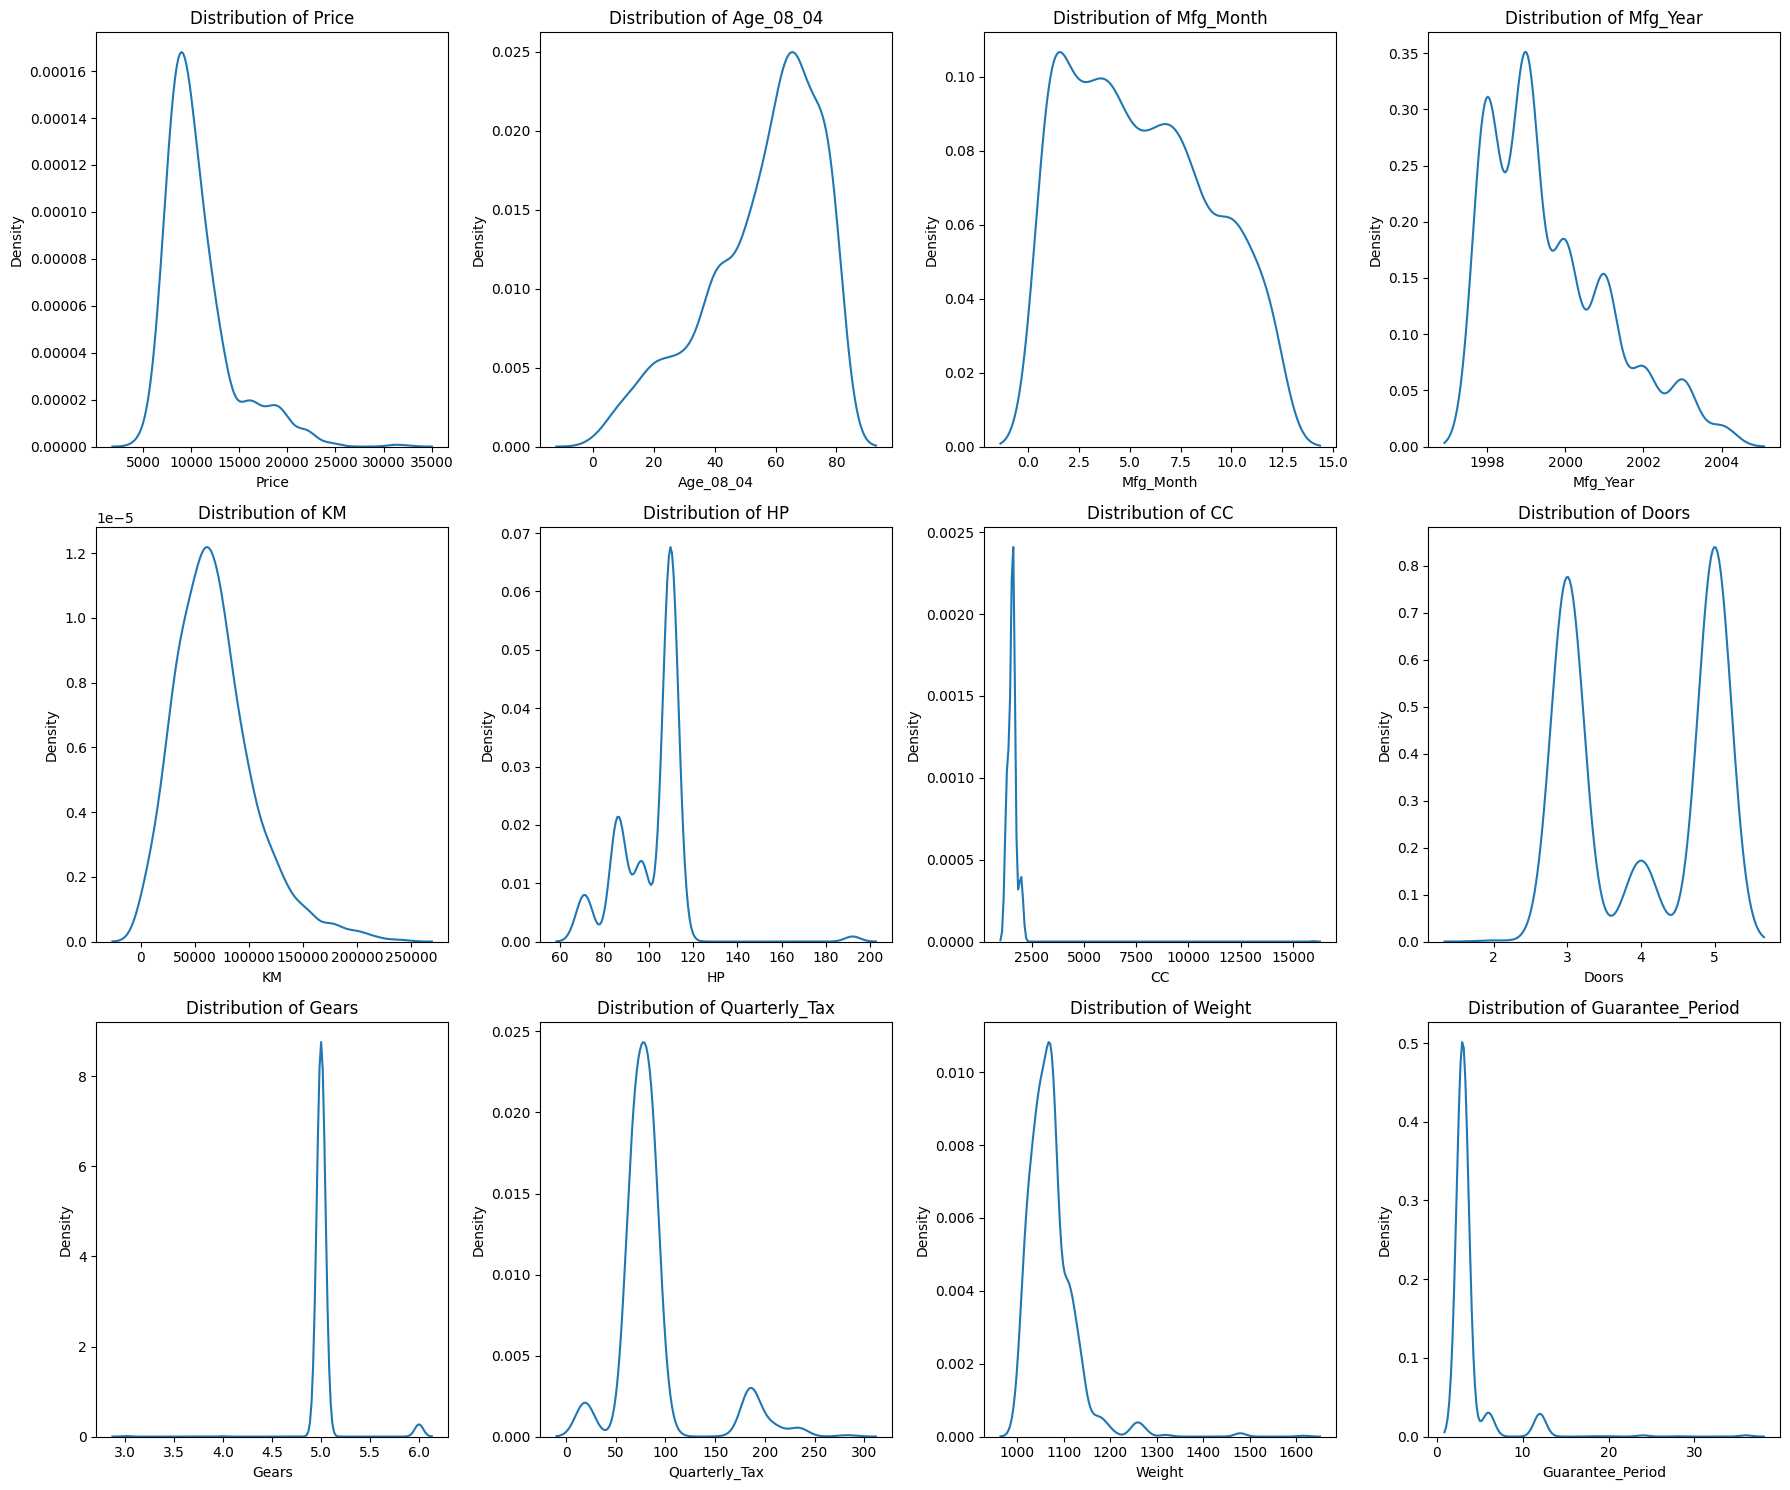

In [512]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(numeric_columns, 1): 
    plt.subplot(3, 4, i)
    sns.kdeplot(data=df, x=column) 
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

По цене много выбросов, и это столбец предсказаний, видимо удалять выбросы, тк логарифмирование не помогло от выбросов

Age_08_04 смещены и есть выбросы в нуле

Mfg_year смещены, есть много малых значений

KM - выбросы логичны, менять не стоит

HP выброс 1 и смещены данные

CC - выброс есть, лучше удалить
Gears - так и должно быть
Quartetrly_Tax - выбросы
weight - выбросы
guarantee_period - дискретный признак, норм


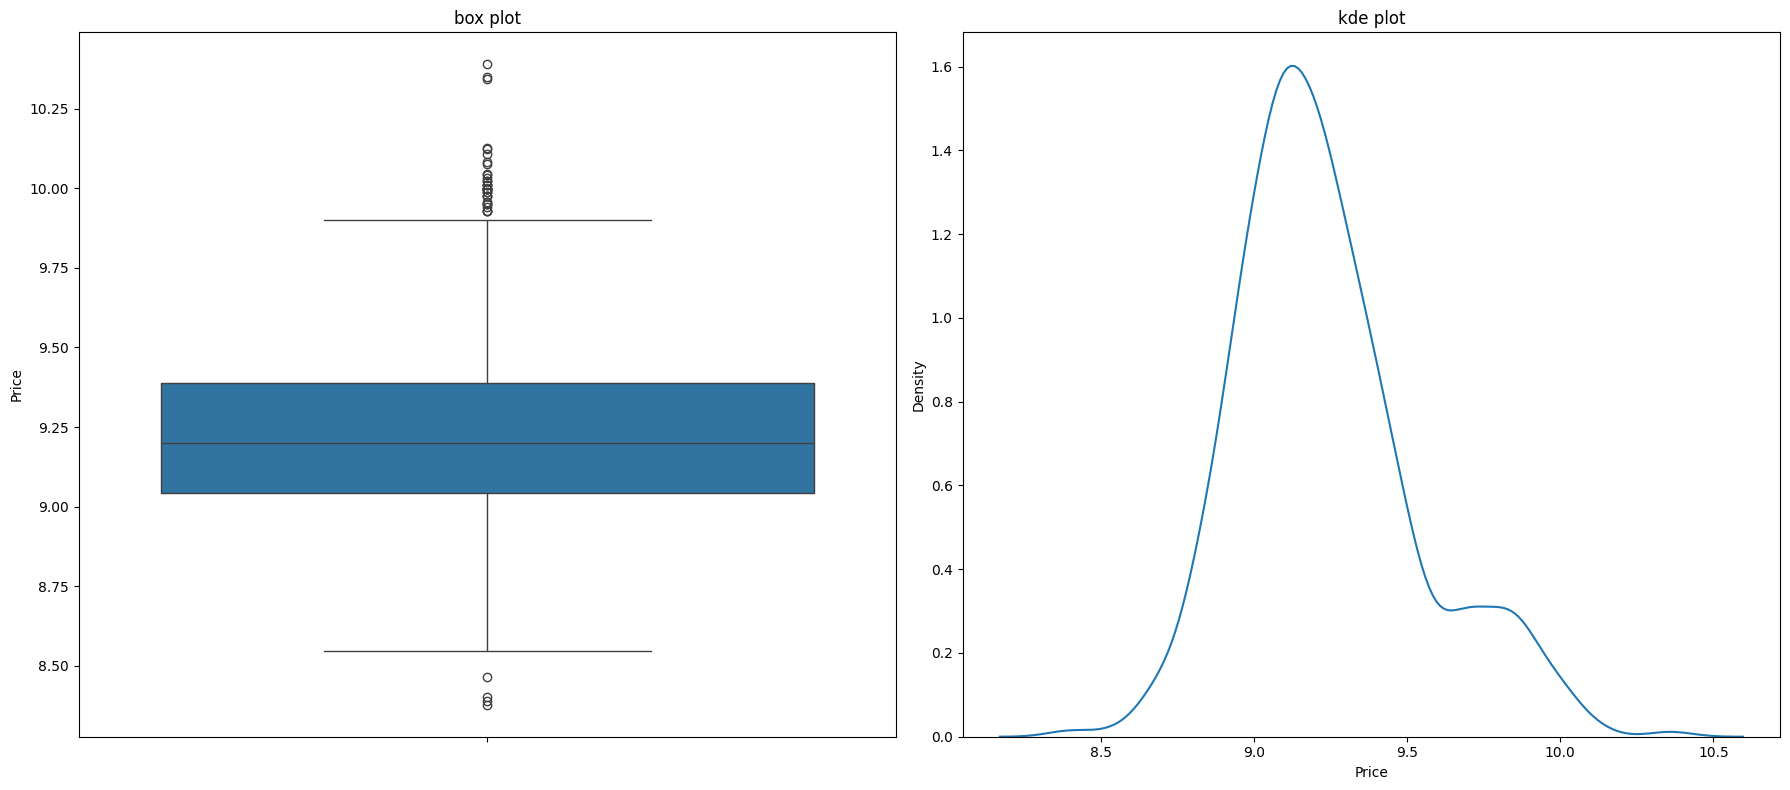

In [513]:
df2 = df.copy()
df2['Price'] = np.log1p(df2['Price'])
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.title(f'box plot')
sns.boxplot(data=df2, y='Price')

plt.subplot(1, 2, 2)
plt.title(f'kde plot')
sns.kdeplot(data=df2, x='Price')

plt.tight_layout()
plt.show()
                        

решение что делать с выбросами:

удалить 5 процентов сверху у 'Price','Age_08_04', 'KM', 'Weight', 'HP', 'CC'

In [514]:
df_clean = df.copy()
cols_to_trim_up = ['Price', 'KM', 'Weight', 'HP', 'CC']


limits = {}

for col in cols_to_trim_up:
    limits[f'{col}_up'] = df[col].quantile(0.95)



mask = pd.Series([True] * len(df), index=df.index)

for col in cols_to_trim_up:
    mask &= (df[col] <= limits[f'{col}_up'])

df_clean = df[mask].copy()

print(f"Было радкоў: {len(df)}, стала пасля чысткі: {len(df_clean)}")
print(f"Выдалена ўсяго: {len(df) - len(df_clean)} радкоў")


Было радкоў: 1435, стала пасля чысткі: 1260
Выдалена ўсяго: 175 радкоў


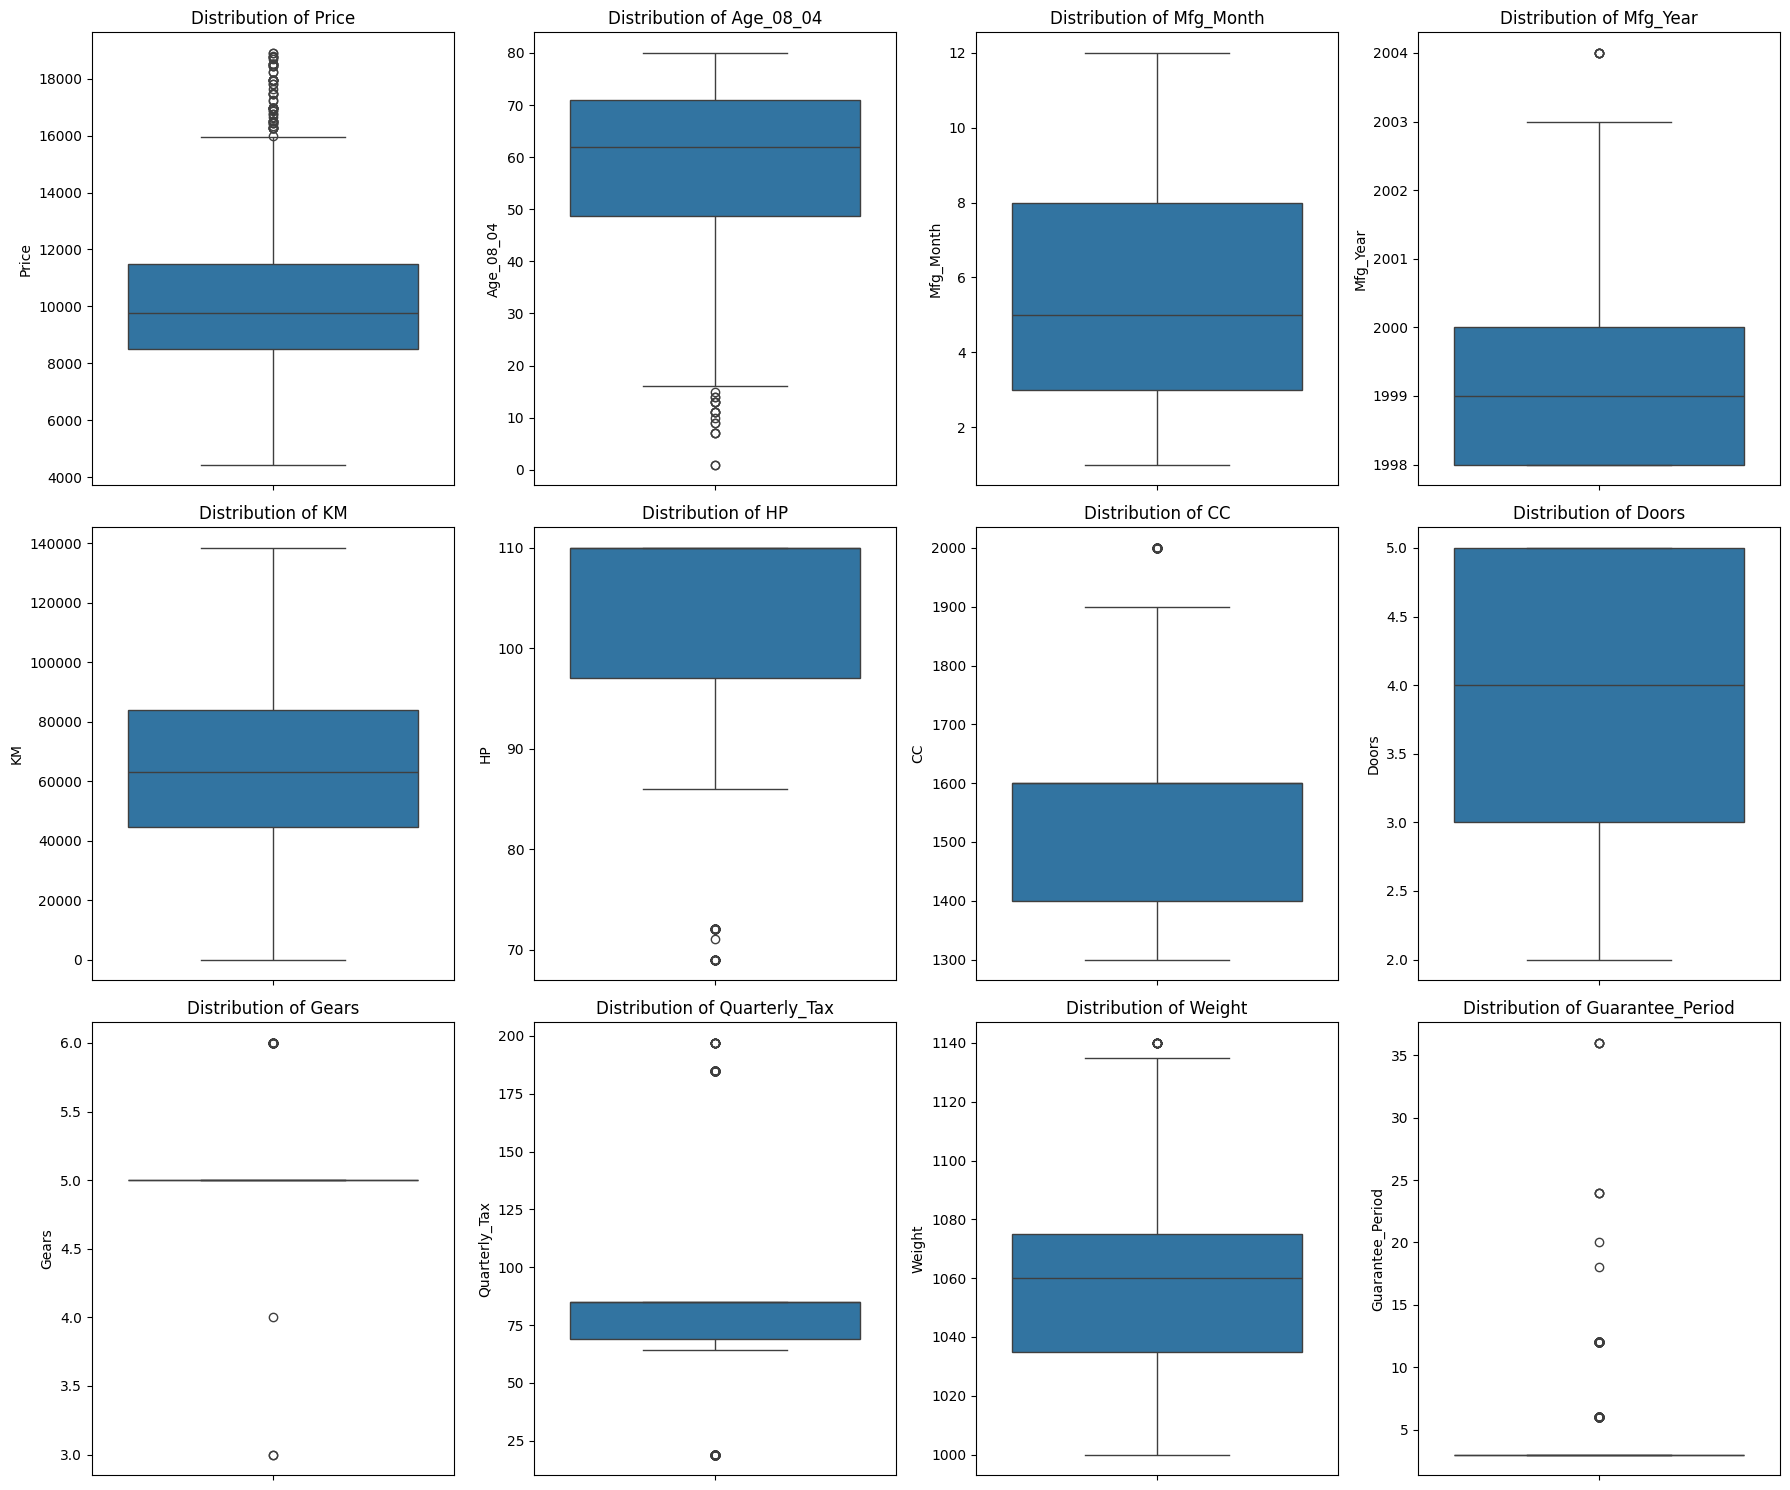

In [515]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(numeric_columns, 1): 
    plt.subplot(3, 4, i)
    sns.boxplot(data=df_clean, y=column) 
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

Корреляция:

<Axes: >

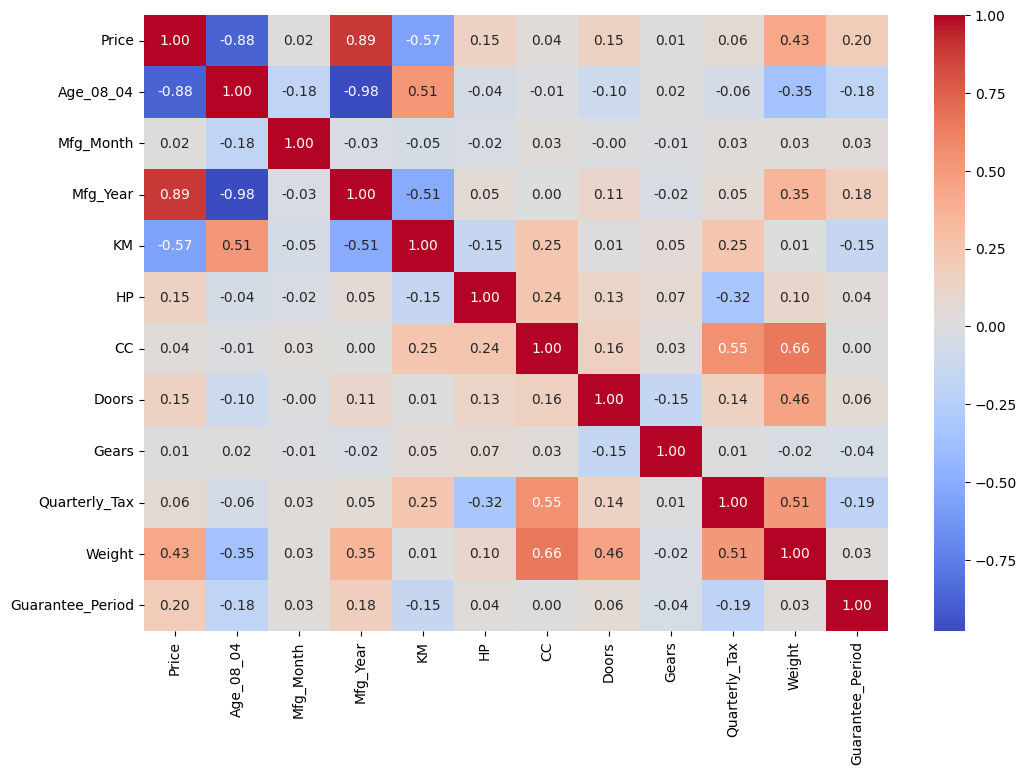

In [516]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")

По матрице корреляции:

обратная линейная зависимость между Mfg_Year и Age_08_04 - одно из них необходимо удалить

Также видна линейная зависимость между таргетом price и Mfg_Year и KM

### Вопросы:

- Как вы предобрабатывали данные?

удалить выбросы, дубликаты как 5 процентов свреху

- Что вы поняли, проведя EDA?

в датасете много выбросов, многие признаки смещены, есть категориальные признаки, есть линейная зависисмоть между признаками.


## 3. Работа с признаками

Как описано выше удалим признаки Mfg_Month и Mfg_Year, тк Age_08_04: The age of the car in months as of August 2004 достаточно
и удаляется Mfg_Year изза скореллированности признаков 

In [517]:
df_clean = df_clean.drop(columns=['Mfg_Month', 'Mfg_Year'])

In [518]:
df1 = pd.DataFrame([
    [col, df_clean[col].dtype, df_clean[col].nunique()] 
    for col in df_clean.columns
], columns=['Column', 'Dtype', 'Unique_Count'])
df1

,Column,Dtype,Unique_Count
0,Model,str,255
1,Price,int64,191
2,Age_08_04,int64,72
3,KM,int64,1112
4,Fuel_Type,str,3
5,HP,int64,9
6,Met_Color,int64,2
7,Color,str,10
8,Automatic,int64,2
9,CC,int64,10


In [519]:
df1[df1['Dtype']=='str']

,Column,Dtype,Unique_Count
0,Model,str,255
4,Fuel_Type,str,3
7,Color,str,10


23 из 38 признако имеют значение 0 или 1, трогать не надо

Требуется перекодирование строковых признаков 
- Model более 300 значений - label encoding
- Fuel_Type  - one-hot encoding
- Color   - 10 значений label encoding
- Cylinders  - только одно значений, признак выкинуть

In [520]:
df_clean = df_clean.drop(columns='Cylinders')

In [521]:
''' 

one-hot encoding for fuel type with k-1 parmatrs (add 2 columns of 3)

'''

df_encoded = pd.get_dummies(df_clean, columns=['Fuel_Type'], drop_first=True, dtype=int)

In [522]:
df_encoded.shape

(1260, 36)

In [523]:
label_encoder = preprocessing.LabelEncoder()

df_encoded['Model']= label_encoder.fit_transform(df_encoded['Model'])+1

df_encoded['Model'].unique()

array([219, 190, 120,  96,  95,  74,  52,  51,  50,  57,  56, 107,  98,
       183,  62,  53, 100,  99,  71, 129,  69,  97, 187, 186,  55, 205,
         2, 204, 114,  54,  63,  75, 208, 184, 209, 216, 222, 226, 225,
        59, 111, 218, 228, 103, 109, 108, 180, 112, 115, 105,  60, 253,
        58, 192, 220, 110, 101,  81, 119, 137, 178, 207, 212, 116, 171,
        72,  66, 130, 176, 102, 197, 215, 211, 106, 181, 113, 198,  15,
       191, 169,  73, 224, 233, 217, 221, 239,  85, 128, 146, 231,   8,
       247, 185, 152,  68, 134, 133, 223,   5,  61, 117, 202, 175, 227,
       254,  83,   1,  67, 189, 122,  64,  87,  27,  41, 251, 148, 104,
        13,  79, 123,  65,  24, 246,  70,  76, 230, 240, 234, 188,  93,
        94, 135, 124,   6,  14,  77, 237, 159, 142,  17,  35,  23, 235,
        43,  21, 144, 206, 136, 162,  91,  16, 179, 126,  88, 255, 143,
       194,  34,  28,  80, 151, 168,   3, 131, 125,  11, 173,   9, 242,
        10,  92,  46, 249,   7, 213, 165, 145,  22, 244, 195, 11

In [524]:
label_encoder = preprocessing.LabelEncoder()

df_encoded['Color'] = label_encoder.fit_transform(df_encoded['Color'])+1

df_encoded['Color'].unique()

array([ 3,  5,  2,  7,  4,  6, 10,  9,  8,  1])

In [525]:
df1[(df1['Unique_Count']>2)&(df1['Dtype'] =='int64')]

,Column,Dtype,Unique_Count
1,Price,int64,191
2,Age_08_04,int64,72
3,KM,int64,1112
5,HP,int64,9
9,CC,int64,10
10,Doors,int64,4
12,Gears,int64,4
13,Quarterly_Tax,int64,7
14,Weight,int64,37
17,Guarantee_Period,int64,7


Маштабирование:

Для признаков
- KM	(standartscaler)
- HP (RobustScaler)
- CC	(RobustScaler)
- Quarterly_Tax	(RobustScaler)
- Weight (standartscaler)
- Guarantee_Period (RobustScaler)

тк где мало уникальных значений, там дискретный вид, и данные не распределены нормально, то нормализация не сохранит ценной информации, лучше RobustScaler устойчивый к выбросам

Само маштабирование будет проделано после разделения выборки на обучающую и тестовую

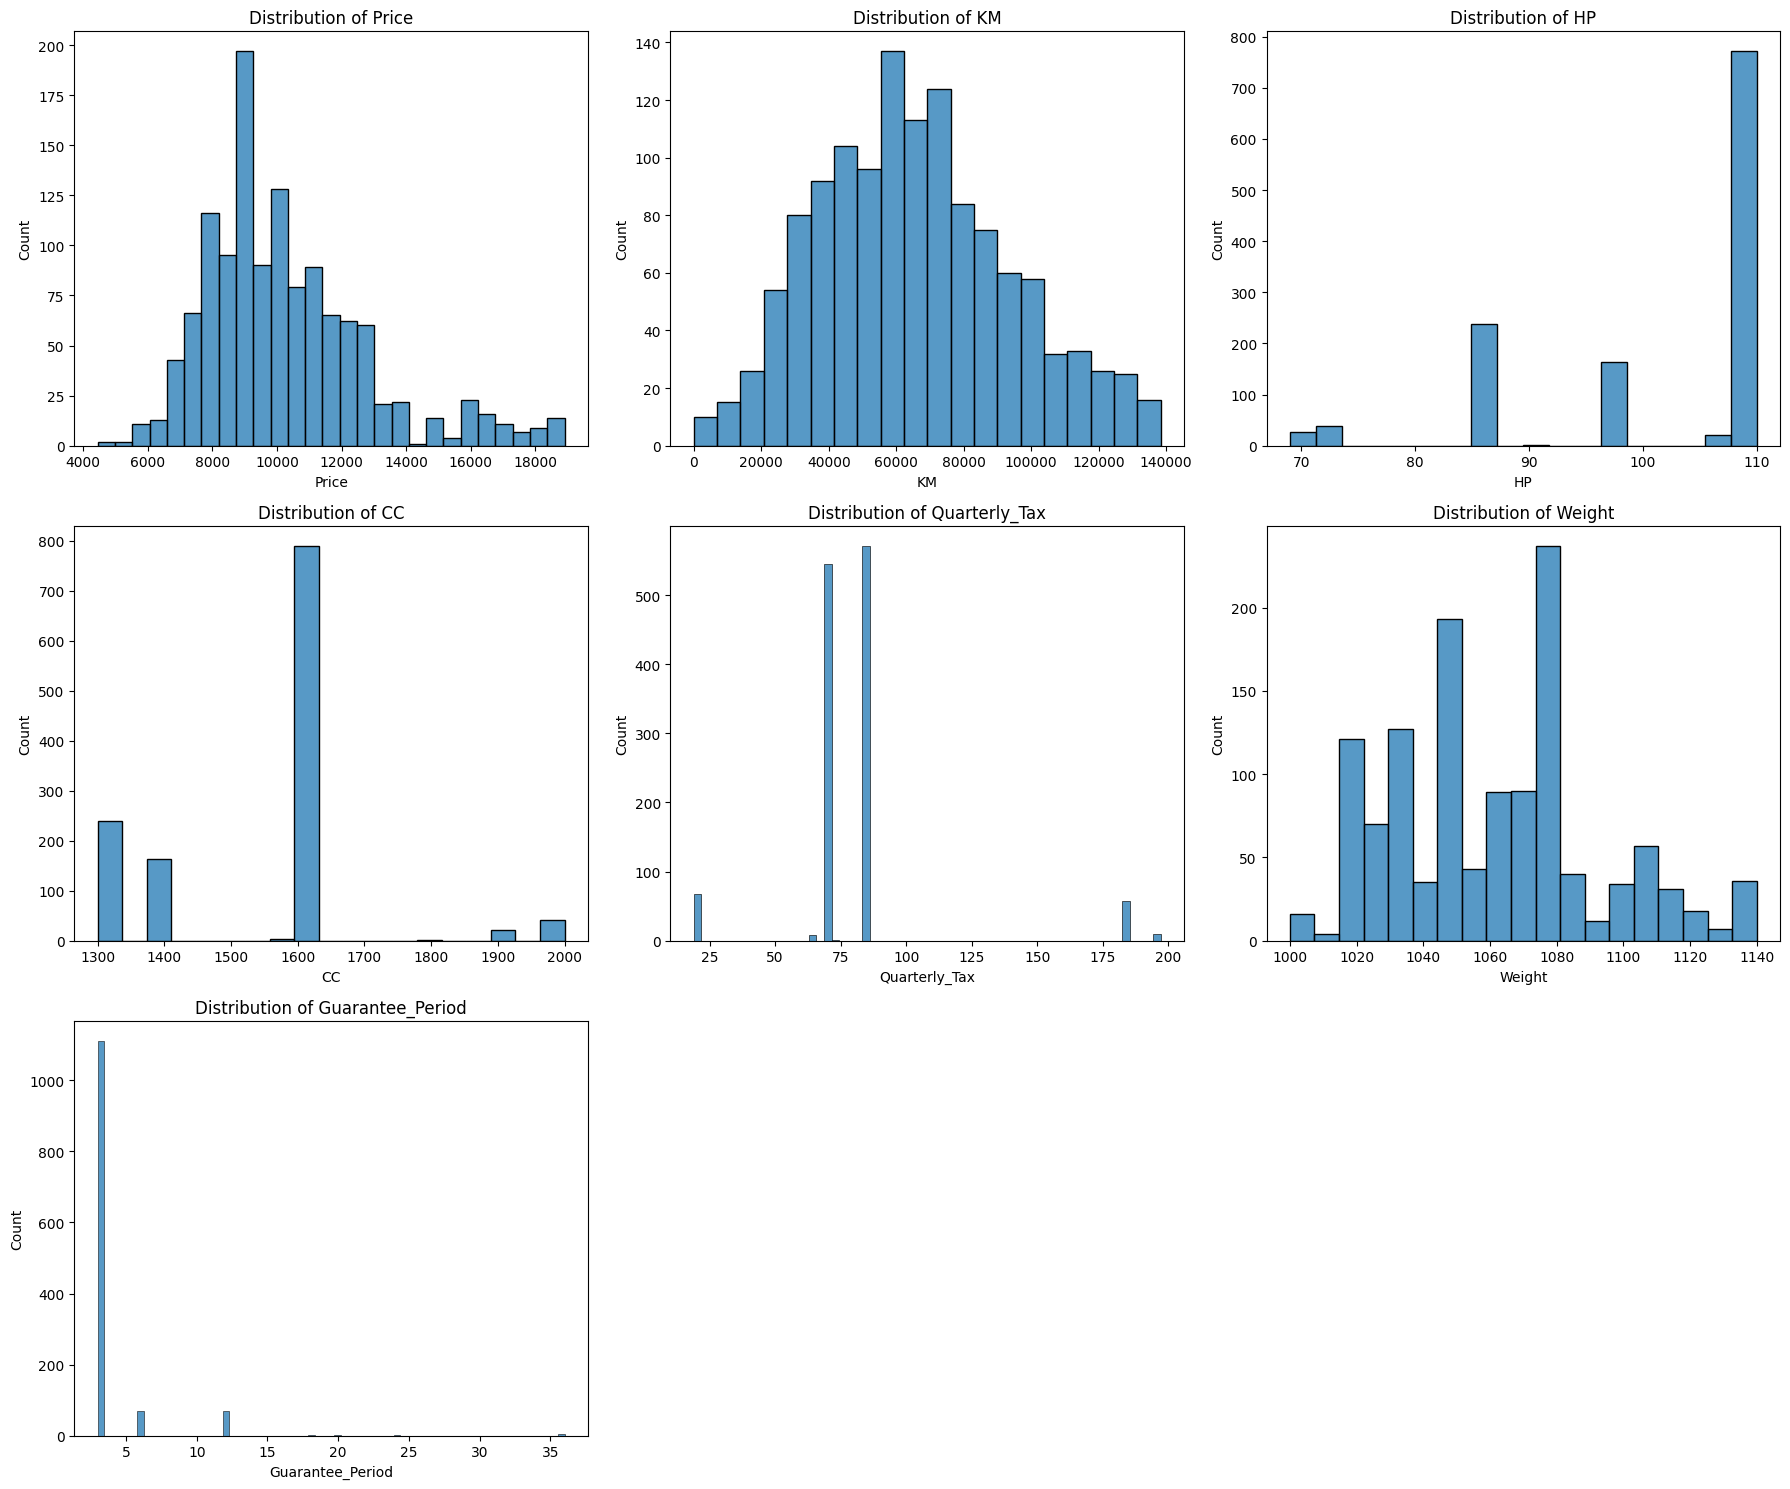

In [526]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(['Price','KM', 'HP', 'CC', 'Quarterly_Tax', 'Weight', 'Guarantee_Period'], 1): 
    plt.subplot(3, 3, i)
    sns.histplot(data=df_encoded, x=column)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

### Вопросы:
- Как вы работали с признаками?

Оценка количества значений(2 или больше), кодирование категориальных

- Какие признаки вы добавили / изменили и почему?

Закодировали категориальные в one-hot encoding и label encoding (со сдвигом, чтобы первая метка была 1, а не 0)

- Какие признаки вы удалили и почему?

Удалили Mfg_Month и Mfg_Year, поскольку между Mfg_Year и Age_08_04 есть обратная линейная зависимость, а Age_08_04 = (Mfg_Year-1998)+Mfg_Month, лучше оставить 1 признак, вместо 2 идентичных

удалили Cylinders, как бесполезный признак с одним значением


## 4. Разделение выборки

Разделение выборки на тестовую и обучающую

In [527]:
X = df_encoded.drop(columns='Price')
y = df_encoded['Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((882, 35), (378, 35), (882,), (378,))

Подготовка данных и наконец-то маштабирование:
- KM	(standartscaler)
- HP (RobustScaler)
- CC	(RobustScaler)
- Quarterly_Tax	(RobustScaler)
- Weight (standartscaler)
- Guarantee_Period (RobustScaler)

In [528]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


robust_cols = ['HP', 'CC', 'Quarterly_Tax', 'Guarantee_Period']

standard_cols = ['Weight', 'KM']


preprocessor = ColumnTransformer([
('std', StandardScaler(), standard_cols),
('rob', RobustScaler(), robust_cols),
], remainder='passthrough')

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

Далее для сравнения будут проводится подсчеты для 4 моделей:
- с логарифмированными ценами
- логарифм + маштабирование
- маштабирование
- просто

### Вопросы:

- Как именно вы разделили выборку?

Train, test

- Для чего это нужно? Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?

Утчека данных получится с завышенным результатом.

## 5. Обучение моделей

Функция для печати оценок:

In [529]:
def get_metrics(y_true, y_pred):
    return {
        'MAE': metrics.mean_absolute_error(y_true, y_pred),
        'MAPE' : metrics.mean_absolute_percentage_error(y_true, y_pred),
        'MSE': metrics.mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(metrics.mean_squared_error(y_true, y_pred)),
        'R^2': metrics.r2_score(y_true, y_pred)
    }

Обучение базовой линейной регрессии:

In [530]:
reg = LinearRegression()

reg.fit(X_train_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [531]:
print("model score: %.3f" % reg.score(X_test_transformed, y_test))

model score: 0.851


In [532]:
y_pred = reg.predict(X_test_transformed)

Сравнение метрик для обучающей и тестовой выборки(проверка на переобучение):

In [533]:
def get_all_results(model, X_train, y_train_orig, X_test, y_test_orig, y_transformer=None, is_log=False):
    # Прагнозы ў трансфармаванай шкале
    train_pred_raw = model.predict(X_train).reshape(-1, 1)
    test_pred_raw = model.predict(X_test).reshape(-1, 1)
    
    # 1. Адваротнае маштабаванне (калі было)
    if y_transformer:
        train_pred_raw = y_transformer.inverse_transform(train_pred_raw)
        test_pred_raw = y_transformer.inverse_transform(test_pred_raw)
        
    # 2. Адваротны лагарыфм (калі быў)
    if is_log:
        train_pred = np.expm1(train_pred_raw).flatten()
        test_pred = np.expm1(test_pred_raw).flatten()
    else:
        train_pred = train_pred_raw.flatten()
        test_pred = test_pred_raw.flatten()
    
    m_train_dict = get_metrics(y_train_orig, train_pred)
    m_test_dict = get_metrics(y_test_orig, test_pred)
    
    # 2. Ператвараем слоўнікі ў Series, каб concat спрацаваў
    m_train = pd.Series(m_train_dict)
    m_test = pd.Series(m_test_dict)
    
    # 3. Цяпер concat будзе працаваць (axis=1 створыць слупкі для Train і Test)
    res = pd.concat([m_train, m_test], axis=1).T
    res.index = ['Train', 'Test']
    return res


# --- 1. ПРОСТА (Original) ---
model_orig = LinearRegression().fit(X_train_transformed, y_train)
res_orig = get_all_results(model_orig, X_train_transformed, y_train, X_test_transformed, y_test)

# --- 2. МАСШТАБАВАННЕ (Scale) ---
sc_y = RobustScaler()
y_train_sc = sc_y.fit_transform(y_train.values.reshape(-1, 1))
model_sc = LinearRegression().fit(X_train_transformed, y_train_sc)
res_scale = get_all_results(model_sc, X_train_transformed, y_train, X_test_transformed, y_test, y_transformer=sc_y)

# --- 3. ЛАГАРЫФМ (Log) ---
model_log = LinearRegression().fit(X_train_transformed, np.log1p(y_train))
res_log = get_all_results(model_log, X_train_transformed, y_train, X_test_transformed, y_test, is_log=True)

# --- 4. ЛАГАРЫФМ + МАСШТАБАВАННЕ (Log + Scale) ---
sc_log = RobustScaler()
y_log_sc = sc_log.fit_transform(np.log1p(y_train).values.reshape(-1, 1))
model_log_sc = LinearRegression().fit(X_train_transformed, y_log_sc)
res_log_scale = get_all_results(model_log_sc, X_train_transformed, y_train, X_test_transformed, y_test, y_transformer=sc_log, is_log=True)

# Зводная табліца для параўнання
final_comparison = pd.concat([res_orig, res_scale, res_log, res_log_scale], 
                             keys=['Original', 'Only Scale', 'Only Log', 'Log + Scale'])
final_comparison

MAE      MAPE            MSE        RMSE       R^2
Original    Train  719.055259  0.074535  871952.340467  933.783883  0.870119
            Test   769.780900  0.078340  964121.268682  981.896771  0.851159
Only Scale  Train  719.055259  0.074535  871952.340467  933.783883  0.870119
            Test   769.780900  0.078340  964121.268682  981.896771  0.851159
Only Log    Train  711.046568  0.073038  858048.122646  926.308870  0.872190
            Test   748.458823  0.075629  938817.283326  968.925840  0.855065
Log + Scale Train  711.046568  0.073038  858048.122646  926.308870  0.872190
            Test   748.458823  0.075629  938817.283326  968.925840  0.855065

Лучший результат с логарифмированием или логарифм + масшиабирование

In [534]:
res_log = np.expm1(model_log.predict(X_test_transformed))
res_log_sc = np.expm1(sc_log.inverse_transform(model_log_sc.predict(X_test_transformed).reshape(-1, 1)))
                      

Метрики на тестовой и обучающей выборки не отличются слишком сильно, все норм - нет переобучения

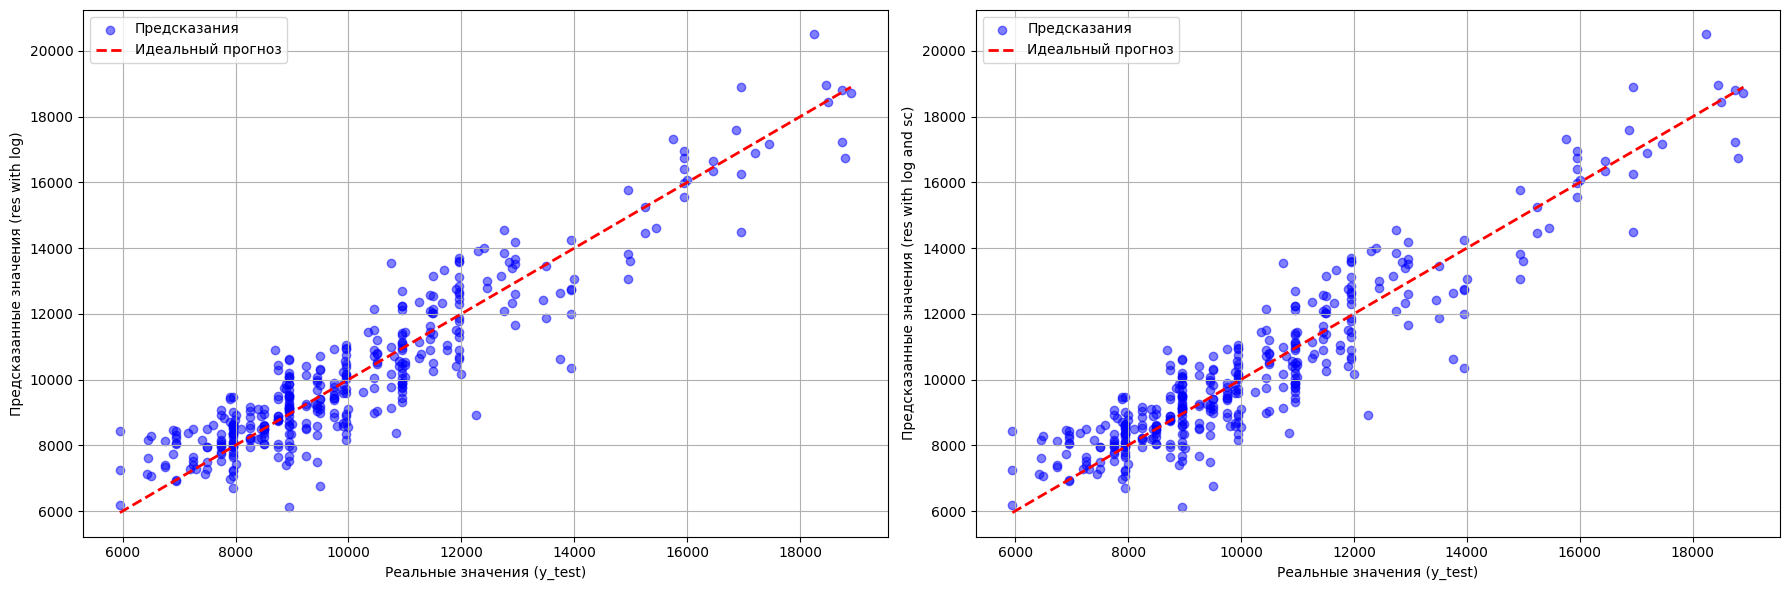

In [535]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, res_log, alpha=0.5, color='blue', label='Предсказания')

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Идеальный прогноз')

plt.xlabel('Реальные значения (y_test)')
plt.ylabel('Предсказанные значения (res with log)')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)

plt.scatter(y_test, res_log_sc, alpha=0.5, color='blue', label='Предсказания')

plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Идеальный прогноз')

plt.xlabel('Реальные значения (y_test)')
plt.ylabel('Предсказанные значения (res with log and sc)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

На вид масштабирование вообще не помогло

Обучение модели с регуляризацией:

L2 регуляризация:

Требуется найти гиперпараметр alpha, с помощью кросс-валидации RidgeCV()

In [536]:
regL2 = RidgeCV(alphas=np.logspace(-1, 1, 200), scoring='neg_mean_squared_error', cv=KFold(n_splits=10))

In [537]:
model_orig = regL2.fit(X_train_transformed, y_train)
res_orig = get_all_results(model_orig, X_train_transformed, y_train, X_test_transformed, y_test)

# --- 2. МАСШТАБАВАННЕ (Scale) ---
sc_y = RobustScaler()
y_train_sc = sc_y.fit_transform(y_train.values.reshape(-1, 1))
model_sc = regL2.fit(X_train_transformed, y_train_sc)
res_scale = get_all_results(model_sc, X_train_transformed, y_train, X_test_transformed, y_test, y_transformer=sc_y)

# --- 3. ЛАГАРЫФМ (Log) ---
model_log = regL2.fit(X_train_transformed, np.log1p(y_train))
res_log = get_all_results(model_log, X_train_transformed, y_train, X_test_transformed, y_test, is_log=True)

# --- 4. ЛАГАРЫФМ + МАСШТАБАВАННЕ (Log + Scale) ---
sc_log = RobustScaler()
y_log_sc = sc_log.fit_transform(np.log1p(y_train).values.reshape(-1, 1))
model_log_sc = regL2.fit(X_train_transformed, y_log_sc)
res_log_scale = get_all_results(model_log_sc, X_train_transformed, y_train, X_test_transformed, y_test, y_transformer=sc_log, is_log=True)

# Зводная табліца для параўнання
final_comparison = pd.concat([res_orig, res_scale, res_log, res_log_scale], 
                             keys=['Original', 'Only Scale', 'Only Log', 'Log + Scale'])
final_comparison

MAE      MAPE            MSE        RMSE       R^2
Original    Train  719.906552  0.074707  875835.648711  935.860913  0.869541
            Test   767.406215  0.078136  961838.772043  980.733793  0.851511
Only Scale  Train  719.906552  0.074707  875835.648711  935.860913  0.869541
            Test   767.406215  0.078136  961838.772043  980.733793  0.851511
Only Log    Train  709.643140  0.073046  856889.995353  925.683529  0.872363
            Test   744.859404  0.075262  927283.942691  962.955836  0.856846
Log + Scale Train  709.643140  0.073046  856889.995353  925.683529  0.872363
            Test   744.859404  0.075262  927283.942691  962.955836  0.856846

Аналогично лучше результат на логарифме и лог+ масштабирование

Также регуляризация несильно, но улучшила предсказания

Как видно по метрикам переобучения не произошло, результат ожидаемо ниже на тестовой выборке чем на обучающей

In [538]:
model_log = regL2.fit(X_train_transformed, np.log1p(y_train))
res_log_L2 = np.expm1(model_log.predict(X_test_transformed))

sc_log = RobustScaler()
y_log_sc = sc_log.fit_transform(np.log1p(y_train).values.reshape(-1, 1))
model_log_sc = regL2.fit(X_train_transformed, y_log_sc)
res_log_sc_L2 = np.expm1(sc_log.inverse_transform(model_log_sc.predict(X_test_transformed).reshape(-1, 1)))

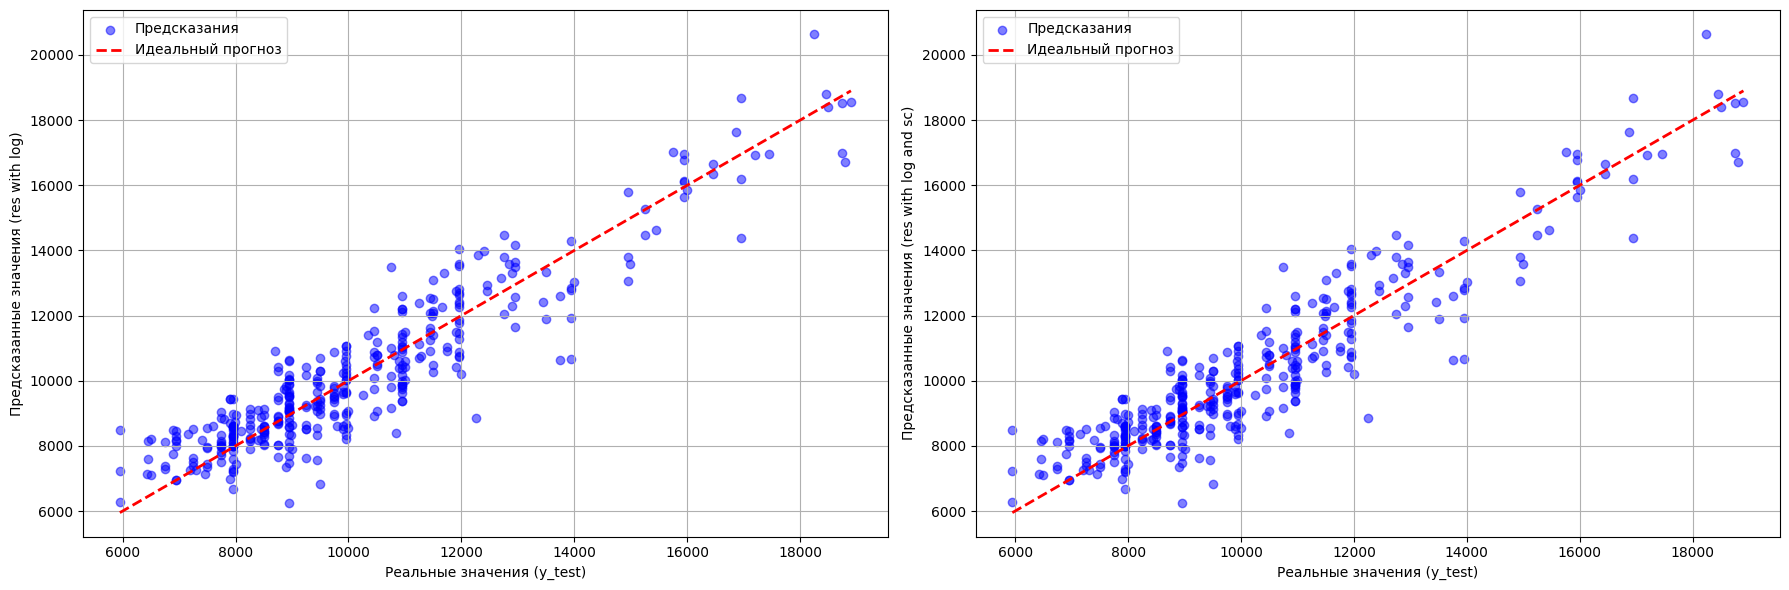

In [539]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, res_log_L2, alpha=0.5, color='blue', label='Предсказания')

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Идеальный прогноз')

plt.xlabel('Реальные значения (y_test)')
plt.ylabel('Предсказанные значения (res with log)')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)

plt.scatter(y_test, res_log_sc_L2, alpha=0.5, color='blue', label='Предсказания')

plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Идеальный прогноз')

plt.xlabel('Реальные значения (y_test)')
plt.ylabel('Предсказанные значения (res with log and sc)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

- Сравнение скорости: если вы учили несколько разных моделей или использовали подбор гиперпараметров (например, коэффициента регуляризации alpha ), сравните, какая модель обучалась быстрее и почему.

для регуляризации использовалась RidgeCV, понятно что с подбором параметров потребовалось больше времени

## 6. Оценка качества и сравнение моделей

Сразу сравниваем только маштабирование с логарифмированием( отдельно логарифм даст оот же результат)

In [540]:
sc_log = RobustScaler()
y_log_sc = sc_log.fit_transform(np.log1p(y_train).values.reshape(-1, 1))
model_log_sc = LinearRegression().fit(X_train_transformed, y_log_sc)
metrics_reg = get_all_results(model_log_sc, X_train_transformed, y_train, X_test_transformed, y_test, y_transformer=sc_log, is_log=True)



sc_log = RobustScaler()
y_log_sc = sc_log.fit_transform(np.log1p(y_train).values.reshape(-1, 1))
model_log_sc = regL2.fit(X_train_transformed, y_log_sc)
metrics_l2 = get_all_results(model_log_sc, X_train_transformed, y_train, X_test_transformed, y_test, y_transformer=sc_log, is_log=True)


In [541]:
df_comparison = pd.DataFrame([
    metrics_reg.loc['Test'], 
    metrics_l2.loc['Test']
], index=['Regression', 'RegL2'])
df_comparison

,MAE,MAPE,MSE,RMSE,R^2
Regression,748.458823,0.075629,938817.283326,968.925840,0.855065
RegL2,744.859404,0.075262,927283.942691,962.955836,0.856846


RMSE больше чем MAE, значит в данных много выбросов, ну это было понятно изначально

Но разница между моделями минимальна, видно из $R^2$ - отличается только в 3 порядкке

В среднем обе модели ошибаются на 7,5%(mape)


Ответьте на следующие вопросы:

1. Какие метрики вы использовали для сравнения моделей? (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен
$R^2$?).

Для справнения моделей использовали MAE, тк таргетом явлется цена квартиры, но в данных есть выбросы. Для модели с регуляризацией MAE ниже, значит предсказания точнее

$R^2$ - удобнее интерпретация MSE, где адекватные значения лежат в интервале [0, 1], оценка насколько модель лучше просто угадывания среднего(R^2=0)

2. На какой части выборки вы считали метрики?

на тестовой

3. Какая модель по итогу справилась лучше?

С логарифмированными и масштабированными таргетами(ценами)

с регуляризацией, но лучше не сильно.

4. Насколько хорошие получились результаты?

В среднем обе модели ошибаются на 7,5%(mape)

5. Чем докажете, что ваша модель не переобучилась?

Что на независимой тестовой выборке оценки не сильно упали, чем на обучающей выборке.